## Шаг 1 - анализ представленных датасетов

---

1. Распределение высот
2. Сколько пропусков
3. Насколько геометрии пересекаются
4. Размеры полигонов
5. Есть ли дубли

In [2]:
# Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

На данном этапе пока что загружаем с сервера. Когда перейдем на локальное выполнение - естественно, что эти файлы будут лежать рядом

In [8]:
source_A = pd.read_csv("https://drive.usercontent.google.com/u/0/uc?id=1CbGYrDmPmG38BqDJH29xE_ifkcJOgeTB&export=download", encoding="utf-8-sig", sep=",", quotechar='"', low_memory=False)

In [5]:
source_B = pd.read_csv("https://drive.usercontent.google.com/u/0/uc?id=1T8zy5cfg54qTwBj7efkbdU4EO551z3i4&export=download")

/tmp/ipykernel_3033/2156584032.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  source_B = pd.read_csv("https://drive.usercontent.google.com/u/0/uc?id=1T8zy5cfg54qTwBj7efkbdU4EO551z3i4&export=download")


In [9]:
source_A.head()

,Unnamed: 0,id,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max
0,0,1,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10095 59.82052, 30.10085 59...",84.94625,NaN,NaN,NaN
1,1,2,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10129 59.82047, 30.10124 59...",114.67415,NaN,NaN,NaN
2,2,3,NaN,['жилое здание'],"MULTIPOLYGON (((30.16261 59.86339, 30.1626 59....",122.99800,NaN,NaN,NaN
3,3,4,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18159 59.9857, 30.18167 59....",64.16945,NaN,NaN,NaN
4,4,5,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18162 59.98583, 30.1816 59....",170.71815,NaN,NaN,NaN


In [10]:
source_A.isna().sum()

,0
Unnamed: 0,0
id,0
title,164097
tags,0
geometry,0
area_sq_m,0
gkh_address,153215
gkh_floor_count_min,154161
gkh_floor_count_max,153822


Уже по данному выводу мы можем сказать, что с адресами и количеством этажей в выборке А у нас всё тяжело. Как и предупреждалось в описании датасета, здесь мы не увидим полных данных об этажах и адресах. Что делать с этими пропущенными значениями пока не ясно  

In [11]:
source_B.head()

,Unnamed: 0,subject,district,type,locality,type_street,name_street,number,letter,fraction,housing,building,purpose_of_building,stairs,avg_floor_height,height,wkt,id
0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.095068678257853 59.84887228...,1
1,1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.278318962652364 59.96375009...,2
2,2,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,28.0,MULTIPOLYGON (((30.29715832931408 60.012659308...,3
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,23.0,MULTIPOLYGON (((30.29741936528335 59.977966278...,4
4,4,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,49.0,MULTIPOLYGON (((30.306284394781 59.89648495498...,5


In [12]:
source_B.isna().sum()

,0
Unnamed: 0,0
subject,4260
district,3985
type,4887
locality,5173
type_street,73064
name_street,73047
number,0
letter,152341
fraction,159978


Здесь уже становится более ясно. У нас хотя бы есть зацепки по адресам. Пропуски в количестве этажей - 4k из огромного датасета, далее мы решим, что можно сделать с этим. Пропуски по высоте совсем незначительные, фактически - близки к ошибкам. Пропусков по wkt нет вообще

Удаление лишнего "мусорного" столбца

In [13]:
for name, df in {"A": source_A, "B": source_B}.items():
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

Просмотр префиксов WKT

In [53]:
print(source_A["geometry"].astype(str).str.split(" ").str[0].value_counts(dropna=False).head(10))

geometry
POLYGON         171173
MULTIPOLYGON       281
Name: count, dtype: int64


In [16]:
print(source_B["wkt"].astype(str).str.split(" ").str[0].value_counts(dropna=False).head(10))

wkt
POLYGON         161069
MULTIPOLYGON         7
Name: count, dtype: int64


После просмотра типовых префиксов выделим то, что БОЛЬШИНСТВО объектов имеют тип полигон, что не очень хорошо. Что с этим делать далее - пока непонятно

Дальше быстро просмотрим **Базовую статистику** с квантильными хвостами и количеством физически подозрительных значений

In [17]:
num_cols_A = ["area_sq_m", "gkh_floor_count_min", "gkh_floor_count_max"]
num_cols_B = ["number", "stairs", "avg_floor_height", "height"]

In [18]:
print(source_A[num_cols_A].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

                        count        mean          std      min      1%  \
area_sq_m            171454.0  504.232473  1465.012176  0.30575  3.7305   
gkh_floor_count_min   17293.0    6.251663     4.569083  0.00000  1.0000   
gkh_floor_count_max   17632.0    7.318852     5.068480  0.00000  0.0000   

                          5%         50%         95%          99%          max  
area_sq_m            11.2102  118.867175  1916.86305  4824.673825  137682.4383  
gkh_floor_count_min   1.0000    5.000000    16.00000    24.000000      34.0000  
gkh_floor_count_max   2.0000    5.000000    17.00000    25.000000      36.0000  


Первостепенно, анализ показал, что:
1. Ключевой количественный признак здесь — это **area_sq_m**. Распределение площади очень сильно скошено вправо: медиана всего около 118.9 м², а среднее уже 504.2 м². Такая разница между медианой и средним означает длинный хвост больших объектов. То есть в наборе одновременно присутствует масса небольших строений и сравнительно немного очень крупных объектов, которые тянут среднее вверх. Это подтверждается и 99-м перцентилем: 4824.7 м², при максимуме 137682.4 м². Следовательно, площадь нельзя анализировать только через среднее — для неё обязательно нужны квантили, логарифмирование или отсечение хвоста при визуализации.
2. В датасете A есть выраженные выбросы по размеру, но они, скорее всего, не ошибки сами по себе, а смесь разных типов объектов: обычные здания, крупные комплексы, производственные объекты, сооружения и т.д
---
Далее, мы видим, что:
1. Поля **gkh_floor_count_min** и **gkh_floor_count_max** в A формально выглядят реалистично по значениям: медиана у обоих около 5 этажей, 95-й перцентиль — 16–17 этажей, 99-й — 24–25 этажей, максимум — 34–36 этажей. Это похоже на правдоподобное распределение этажности городской застройки. Но критически важно другое: count у этих признаков очень маленький относительно общего числа объектов. Для **gkh_floor_count_min** заполнено только *17293* записей, для **gkh_floor_count_max** — *17632*, тогда как всего в A порядка *171 тыс. объектов*
2. Значит, этажность в датасете A имеет очень низкую полноту и не может быть основной опорой для построения единой модели высоты. Иными словами, A — это прежде всего источник геометрии, площади и, возможно, типа объекта, но не надежный источник вертикальных характеристик. Это полностью согласуется с описанием данных: в датасете A есть только косвенная информация об этажности, причем с низкой полнотой, а высота как таковая дана только в датасете B.

In [19]:
print(source_B[num_cols_B].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

                     count       mean        std  min   1%   5%  50%   95%  \
number            161076.0  17.950235  31.601093  0.0  0.0  0.0  3.0  84.0   
stairs            157075.0   4.547108   5.056544  0.0  1.0  1.0  2.0  15.0   
avg_floor_height  161076.0   3.371179   0.743086  0.0  0.0  3.0  3.0   4.0   
height            161010.0  14.682554  15.167023  2.0  4.0  4.5  6.6  45.0   

                    99%    max  
number            147.0  776.0  
stairs             24.0   87.0  
avg_floor_height    4.0   13.0  
height             78.0  462.0  


Далее мы переходим к датасету B. Здесь уже видно, что он значительно богаче именно с точки зрения высоты. Поля **stairs**, **avg_floor_height** и **height** заполнены почти полностью. Это сразу делает датасет B главным кандидатом на роль основного источника вертикальных параметров здания. Но внутри него заметны и артефакты.
1. Начнем со **stairs**. Медиана — 2 этажа, среднее — 4.55, 95-й перцентиль — 15 этажей, 99-й — 24 этажа, максимум — 87 этажей. Такая картина говорит о том, что в данных доминируют малоэтажные и среднеэтажные объекты, но есть длинный хвост по этажности. До 24 этажей на 99-м перцентиле всё выглядит вполне правдоподобно для крупного города, а вот максимум 87 уже выглядит как сильный кандидат на выброс или по крайней мере на отдельную проверку. То есть основная масса значений реалистична, но хвост надо чистить. (UPD: Лахта-Центр как раз 87 этажей, то есть в целом данные реалистичны)
2. Поле **avg_floor_height** тоже очень показательно. Медиана — 3.0 м, 95-й и 99-й перцентили — 4.0 м, среднее — 3.37 м. Это в целом физически правдоподобно: обычная этажная высота жилых и многих общественных зданий действительно лежит в районе 3–4 метров. Но минимальное значение равно 0, а таких записей довольно много. Это не физический смысл, а кодировка проблемы: либо пропуск, либо ошибка заполнения. Максимум 13 м тоже для “средней высоты этажа” почти наверняка аномален. Значит, **avg_floor_height** полезен, но требует обязательной фильтрации нулей и экстремумов.
3. Поле **height** даёт ещё более интересную картину. Медиана — 6.6 м, среднее — 14.68 м, 95-й перцентиль — 45 м, 99-й — 78 м, максимум — 462 м (Лахта-Центр). Разрыв между median и mean снова показывает сильную правую асимметрию. Основная масса зданий невысокая, но присутствует хвост очень высоких объектов.
4. Для моделирования высоты **number** не надо использовать как обычный numeric feature без специальной обработки.

Далее сделаем пробный парсинг WKT на семпле

In [20]:
from shapely import wkt

In [21]:
def safe_load_wkt(x):
    try:
        return wkt.loads(x) if pd.notna(x) else None
    except Exception:
        return None

In [22]:
sample_A = source_A["geometry"].sample(1000, random_state=42)
sample_B = source_B["wkt"].sample(1000, random_state=42)

parsed_A = sample_A.apply(safe_load_wkt)
parsed_B = sample_B.apply(safe_load_wkt)

In [23]:
print("A parse success rate:", parsed_A.notna().mean())
print("B parse success rate:", parsed_B.notna().mean())

A parse success rate: 1.0
B parse success rate: 1.0


На случайной выборке из 1000 объектов для каждого источника выполнен парсинг WKT. Доля успешно распарсенных геометрий составила 100% для обоих датасетов, что свидетельствует об отсутствии синтаксических ошибок в представлении геометрии и позволяет корректно использовать данные для дальнейшего пространственного анализа

Считаем, сколько объектов выглядят странно

In [24]:
print("A area <= 0:", (source_A["area_sq_m"] <= 0).sum())

A area <= 0: 0


Во всех объектах источника A площадь положительна, значений ≤ 0 не обнаружено. Это свидетельствует об отсутствии очевидных ошибок в атрибуте площади и позволяет использовать **area_sq_m** без дополнительной фильтрации по знаку.

In [25]:
print("A floor_min > floor_max:", (
    source_A["gkh_floor_count_min"].notna() &
    source_A["gkh_floor_count_max"].notna() &
    (source_A["gkh_floor_count_min"] > source_A["gkh_floor_count_max"])
).sum())

A floor_min > floor_max: 420


Обнаружено 420 записей, в которых минимальная этажность превышает максимальную, что противоречит физическому смыслу показателей. Это указывает на ошибки в данных (перепутанные значения или некорректный ввод). Такие записи требуют исправления (например, перестановка значений) или исключения из анализа при использовании этажности.

In [26]:
print("B stairs <= 0:", (source_B["stairs"] <= 0).sum())

B stairs <= 0: 17


Найдено 17 объектов с нулевым или отрицательным числом этажей, что является физически невозможным. Эти значения следует рассматривать как ошибки и либо удалить, либо заменить на пропуски перед дальнейшим использованием признака stairs.

In [27]:
print("B stairs > 100:", (source_B["stairs"] > 100).sum())

B stairs > 100: 0


Значений с аномально большим числом этажей (>100) не обнаружено. Это говорит о том, что верхняя граница признака stairs в целом находится в разумных пределах, и экстремальных выбросов по этому признаку практически нет.

In [28]:
print("B avg_floor_height <= 0:", (source_B["avg_floor_height"] <= 0).sum())

B avg_floor_height <= 0: 4260


Обнаружено 4260 записей с нулевой или отрицательной средней высотой этажа. Такие значения не имеют физического смысла и, вероятно, используются как заглушка для пропущенных данных. Эти записи необходимо интерпретировать как missing values и обрабатывать соответствующим образом

In [29]:
print("B avg_floor_height > 10:", (source_B["avg_floor_height"] > 10).sum())

B avg_floor_height > 10: 2


Найдено 2 объекта с аномально большой средней высотой этажа (>10 м). С учетом того, что типичная высота этажа составляет 3–4 м, такие значения с высокой вероятностью являются ошибками и требуют отдельной проверки или исключения.

In [30]:
print("B height <= 0:", (source_B["height"] <= 0).sum())

B height <= 0: 0


Отрицательных или нулевых значений общей высоты здания не обнаружено. Это подтверждает базовую корректность признака height с точки зрения знака.

In [31]:
print("B height > 300:", (source_B["height"] > 300).sum())

B height > 300: 2


Обнаружено 2 объекта с высотой более 300 метров. Эти значения являются экстремальными, однако могут соответствовать реальным уникальным зданиям (например, высотным доминантам города). Поэтому такие наблюдения не следует автоматически удалять, а необходимо валидировать через другие признаки

Согласованность stairs, avg_floor_height и height в источнике B

In [32]:
b = source_B.copy()

mask = b["stairs"].notna() & b["height"].notna()
b.loc[mask, "height_per_floor"] = b.loc[mask, "height"] / b.loc[mask, "stairs"]

print(b["height_per_floor"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

count    157075.0
mean          inf
std           NaN
min           0.8
1%            3.0
5%            3.0
50%           3.3
95%           4.5
99%           4.5
max           inf
Name: height_per_floor, dtype: float64


Распределение height_per_floor показывает, что для подавляющего большинства объектов высота одного этажа находится в диапазоне 3–4.5 метров, с медианой около 3.3 м, что полностью соответствует реальным строительным нормам.

---
Наличие значений inf связано с делением на ноль (при stairs = 0) и не отражает физическую реальность. Такие записи должны быть исключены из анализа или обработаны как ошибки.

In [33]:
print("height_per_floor < 2:", (b["height_per_floor"] < 2).sum())

height_per_floor < 2: 8


In [34]:
print("height_per_floor > 6:", (b["height_per_floor"] > 6).sum())

height_per_floor > 6: 33


Выявлено крайне малое количество аномальных значений:
- менее 2 м на этаж — 8 объектов
- более 6 м на этаж — 33 объекта

С учетом общего объема данных, это составляет доли процента и может быть связано либо с ошибками в данных, либо с нетипичными объектами (например, промышленными зданиями или сооружениями с нестандартной высотой этажей).

Таким образом, основной массив данных по этажности является физически согласованным и надежным.

In [35]:
mask2 = b["stairs"].notna() & b["avg_floor_height"].notna() & b["height"].notna()
b.loc[mask2, "height_from_stairs"] = b.loc[mask2, "stairs"] * b.loc[mask2, "avg_floor_height"]
b.loc[mask2, "height_error_abs"] = (b.loc[mask2, "height"] - b.loc[mask2, "height_from_stairs"]).abs()

print(b["height_error_abs"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

count    157075.000000
mean          0.490142
std           0.990146
min           0.000000
50%           0.500000
90%           0.900000
95%           1.200000
99%           6.000000
max          70.000000
Name: height_error_abs, dtype: float64


Сравнение фактической высоты здания с расчетной (stairs × avg_floor_height) показывает высокую степень согласованности данных:
- для 50% объектов ошибка составляет не более 0.5 м
- для 95% — не превышает 1.2 м

Это говорит о том, что признаки **height**, **stairs** и **avg_floor_height** в большинстве случаев описывают одну и ту же физическую величину и согласованы между собой.

Небольшие расхождения могут объясняться:
- округлением значений,
- наличием технических этажей,
- вариациями высоты этажей внутри здания.

При этом наличие редких крупных ошибок (до 70 м) указывает на отдельные аномальные записи, требующие дополнительной проверки.

In [36]:
print(source_B["avg_floor_height"].value_counts(dropna=False).head(20))

avg_floor_height
3.0     84252
4.0     72539
0.0      4260
2.0        13
5.0         9
12.0        1
13.0        1
8.0         1
Name: count, dtype: int64


Распределение средней высоты этажа имеет выраженно дискретный характер:
- основная масса значений сосредоточена на 3.0 м и 4.0 м, что соответствует - типичным значениям для жилых и административных зданий;
- значения 0.0 (4260 записей) являются некорректными и, вероятно, используются как замена пропусков;
- редкие значения (2.0, 5.0, 12.0, 13.0) встречаются крайне редко и могут соответствовать либо специфическим типам зданий, либо ошибкам.

Следовательно, **avg_floor_height** является информативным признаком, но требует очистки: значения ≤ 0 должны быть заменены на пропуски.

In [37]:
def plot_hist_clipped(series, title, q=0.99, bins=50):
    s = series.dropna()
    upper = s.quantile(q)
    s = s[s <= upper]
    plt.figure(figsize=(8, 4))
    plt.hist(s, bins=bins)
    plt.title(f"{title} (<= {q:.0%} quantile)")
    plt.show()

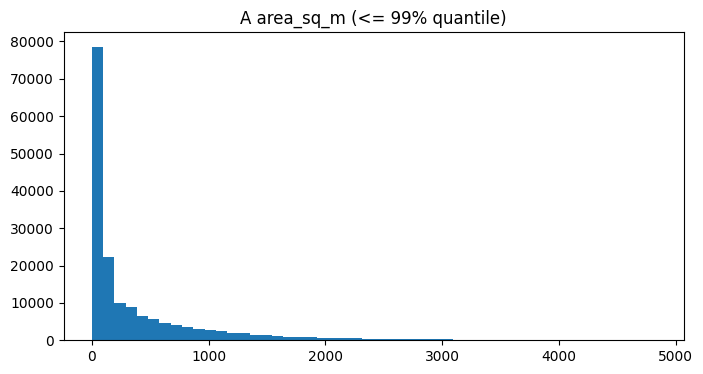

In [38]:
plot_hist_clipped(source_A["area_sq_m"], "A area_sq_m")

Распределение площади зданий имеет выраженную правостороннюю асимметрию:
- основная масса объектов сосредоточена в диапазоне до 200–300 м²
- наблюдается длинный хвост до 5000 м² (99-й перцентиль)
- при этом ранее было видно, что максимумы значительно выше (до 100k+)

Это означает, что в выборке присутствует смесь разных типов объектов:

- небольшие здания (жилые дома, хозяйственные постройки),
- средние (административные, коммерческие),
- крупные (ТЦ, промышленные комплексы).

---

Вывод:
- распределение не является нормальным
- среднее значение нерепрезентативно
- для анализа необходимо использовать: квантили или логарифмирование (log(area))

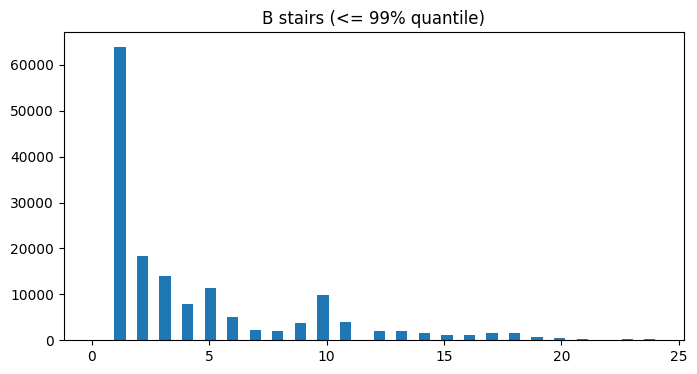

In [39]:
plot_hist_clipped(source_B["stairs"], "B stairs")

Распределение количества этажей имеет характерную для городской застройки форму:
- ярко выраженный пик на 1–2 этажах
- быстрое убывание частоты с ростом этажности
- длинный хвост до ~25 этажей (99-й перцентиль)

Это отражает структуру города:

- доминирует малоэтажная застройка
- присутствует значительное число среднеэтажных зданий
- высокоэтажные объекты встречаются редко

---
Вывод:

- распределение также асимметрично
- данные выглядят реалистично и физически правдоподобно
- хвост не является шумом, а отражает реальные высотные здания

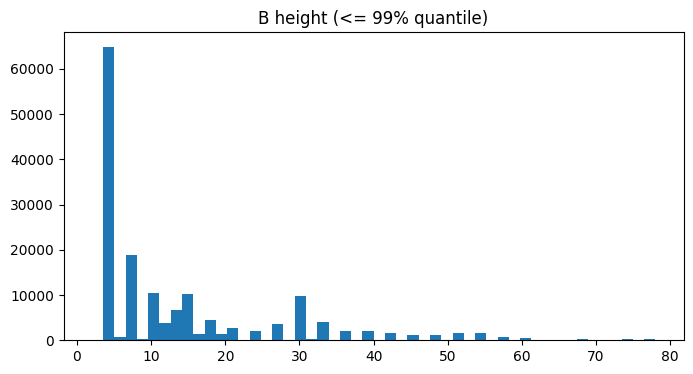

In [40]:
plot_hist_clipped(source_B["height"], "B height")

Распределение высоты зданий аналогично распределению этажности:

- основная масса объектов находится в диапазоне ~5–15 м
- присутствует длинный хвост до ~80 м (99-й перцентиль)
- ранее выявлены экстремальные значения (>300 м)

Наблюдается сильная корреляция с **stairs**, что подтверждает физическую согласованность данных.

Анализ распределений количественных признаков показал, что все ключевые переменные (**area_sq_m**, **stairs**, **height**) имеют выраженную правостороннюю асимметрию и длинный хвост. Это обусловлено неоднородностью объектов в выборке: от малых строений до крупных и высотных зданий. В связи с этим использование средних значений является некорректным, и дальнейший анализ должен опираться на квантильные оценки, логарифмические преобразования и робастные методы

In [41]:
source_A["tags"].value_counts(dropna=False).head(30)

,count
tags,
['жилое здание'],58297
"['постройка, сооружение']",48218
['промышленность'],22565
['бизнес и услуги'],7768
"['Комплекс зданий', 'жилое здание']",5428
['торговля'],5326
['образование'],3933
['офисы'],1945
['медицина'],1548


В датасете A тип здания представлен в виде списка тегов, что отражает:
- возможность множественной классификации объекта
- более гибкую, но менее стандартизированную структуру признака

При этом категории по смыслу сопоставимы с **purpose_of_building** из датасета B.

In [42]:
source_B["purpose_of_building"].value_counts(dropna=False).head(30)

,count
purpose_of_building,
Жилое здание,50231
Нежилое здание,49389
Строение дачное,17031
Производственное здание,15888
Строение жилое (частное),7800
NaN,3964
Административное здание,3795
Учебное учреждение,3198
Торговый центр,2851


Распределение типов зданий показывает, что:

- основную долю составляют жилые и нежилые здания
- присутствует значительное количество дачных строений, производственных объектов, административных и общественных зданий

Это подтверждает, что датасет охватывает широкий спектр городской застройки.

In [43]:
addr_cols_B = [
    "subject", "district", "type", "locality", "type_street",
    "name_street", "number", "letter", "fraction", "housing", "building"
]

((source_B[addr_cols_B].isna().mean() * 100).round(2)).sort_values(ascending=False)

,0
building,99.83
fraction,99.32
letter,94.58
housing,81.04
type_street,45.36
name_street,45.35
locality,3.21
type,3.03
subject,2.64
district,2.47


Что мы видим здесь? Что адресные признаки из датасета B достаточно слабые.
- детализированные компоненты адреса (корпус, строение, литера, дробь) практически полностью отсутствуют и не пригодны для использования;
- названия улиц заполнены лишь примерно наполовину;
- при этом базовые административные признаки (регион, район, населённый пункт) и номер дома заполнены почти полностью.

---

В связи с высокой долей пропусков в адресных полях сопоставление объектов источников A и B по адресам является **ненадежным** и должно выполняться преимущественно на основе пространственного пересечения геометрий

Анализ категориальных признаков показал, что оба источника содержат информацию о типе здания, однако в различном формате: в датасете B — в виде единственной категории (**purpose_of_building**), в датасете A — в виде набора тегов (**tags**). При этом адресные признаки в датасете B обладают высокой долей пропусков и не позволяют выполнять надежное сопоставление объектов. В связи с этим основным механизмом объединения данных должен выступать пространственный анализ, а категориальные признаки следует использовать как дополнительные признаки для валидации и моделирования


In [44]:
has_basic_addr = source_B["name_street"].notna() & source_B["number"].notna()
print("B with basic address:", has_basic_addr.mean())

B with basic address: 0.5465059971690382


Базовый адрес (улица + номер) присутствует лишь примерно у 54.6% объектов датасета B

In [45]:
import geopandas as gpd
from shapely import wkt

In [46]:
source_A["geometry"] = source_A["geometry"].apply(safe_load_wkt)
source_B["geometry"] = source_B["wkt"].apply(safe_load_wkt)

In [47]:
gdf_A = gpd.GeoDataFrame(source_A.copy(), geometry="geometry", crs="EPSG:4326")
gdf_B = gpd.GeoDataFrame(source_B.copy(), geometry="geometry", crs="EPSG:4326")

In [48]:
print("A geometry null:", gdf_A.geometry.isna().sum())

A geometry null: 0


In [49]:
print("B geometry null:", gdf_B.geometry.isna().sum())

B geometry null: 0


Во всех записях обоих источников геометрия присутствует, нет пропусков, следовательно можно использовать в spatial-анализе

In [50]:
print("A invalid geometry:", (~gdf_A.geometry.is_valid).sum())
print("B invalid geometry:", (~gdf_B.geometry.is_valid).sum())

A invalid geometry: 0
B invalid geometry: 0


Все геометрии корректны с точки зрения топологии: нет самопересечений, нет битых полигонов, не требуется исправление геометрии

In [51]:
print("A empty geometry:", gdf_A.geometry.is_empty.sum())
print("B empty geometry:", gdf_B.geometry.is_empty.sum())

A empty geometry: 0
B empty geometry: 0


Пустых геометрий не обнаружено.

С учетом низкой полноты адресных данных и высокой качества геометрии, основным способом сопоставления объектов между источниками A и B должен выступать пространственный анализ на основе пересечения полигонов

In [52]:
print(gdf_A.geom_type.value_counts(dropna=False))
print(gdf_B.geom_type.value_counts(dropna=False))

Polygon         171173
MultiPolygon       281
Name: count, dtype: int64
Polygon         161069
MultiPolygon         7
Name: count, dtype: int64


В обоих источниках подавляющее большинство объектов представлены простыми полигонами, при этом доля мультиполигонов крайне мала:

- в A — около 0.16%
- в B — практически отсутствуют

---

Преобладание простых полигонов упрощает пространственное сопоставление, так как большинство объектов представлены единичными контурами без необходимости их предварительного объединения.

In [56]:
gdf_A_m = gdf_A.to_crs(epsg=3857)
gdf_B_m = gdf_B.to_crs(epsg=3857)

In [57]:
gdf_A_m["centroid"] = gdf_A_m.geometry.centroid
gdf_B_m["centroid"] = gdf_B_m.geometry.centroid

In [58]:
gdf_A_m["centroid_x"] = gdf_A_m["centroid"].x
gdf_A_m["centroid_y"] = gdf_A_m["centroid"].y

gdf_B_m["centroid_x"] = gdf_B_m["centroid"].x
gdf_B_m["centroid_y"] = gdf_B_m["centroid"].y

In [59]:
bounds_A = gdf_A_m.geometry.bounds
bounds_B = gdf_B_m.geometry.bounds

gdf_A_m["bbox_width_m"]  = bounds_A["maxx"] - bounds_A["minx"]
gdf_A_m["bbox_height_m"] = bounds_A["maxy"] - bounds_A["miny"]
gdf_A_m["bbox_area_m2"]  = gdf_A_m["bbox_width_m"] * gdf_A_m["bbox_height_m"]

gdf_B_m["bbox_width_m"]  = bounds_B["maxx"] - bounds_B["minx"]
gdf_B_m["bbox_height_m"] = bounds_B["maxy"] - bounds_B["miny"]
gdf_B_m["bbox_area_m2"]  = gdf_B_m["bbox_width_m"] * gdf_B_m["bbox_height_m"]

In [60]:
print("A centroid null:", gdf_A_m["centroid"].isna().sum())
print("B centroid null:", gdf_B_m["centroid"].isna().sum())

A centroid null: 0
B centroid null: 0


Центроиды успешно вычислены для всех объектов.

In [61]:
print(
    gdf_A_m[["bbox_width_m", "bbox_height_m", "bbox_area_m2"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

                  count         mean           std       min         1%  \
bbox_width_m   171454.0    50.668691     61.427554  1.113195   4.452780   
bbox_height_m  171454.0    51.766227     62.007396  2.210668   4.441261   
bbox_area_m2   171454.0  5343.142407  20196.002060  2.466149  24.673318   

                      5%         50%           95%           99%           max  
bbox_width_m    7.792364   28.943068    159.186872    296.109846  2.148466e+03  
bbox_height_m   8.865132   28.843545    171.049881    301.306922  1.909054e+03  
bbox_area_m2   74.201667  833.023890  22280.392067  67306.533758  3.421490e+06  


Размеры bounding box демонстрируют значительную вариативность объектов — от небольших зданий до крупных комплексов. При этом bounding box систематически переоценивает реальную площадь, поэтому должен использоваться как вспомогательный признак (например, для оценки формы и масштаба), но не как замена фактической площади

In [62]:
print(
    gdf_B_m[["bbox_width_m", "bbox_height_m", "bbox_area_m2"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

                  count         mean           std       min         1%  \
bbox_width_m   161076.0    51.805851     63.686968  0.779236   7.792364   
bbox_height_m  161076.0    52.610367     62.519676  1.110060   7.345154   
bbox_area_m2   161076.0  5532.160124  23059.057104  2.594998  67.883179   

                       5%         50%           95%           99%  \
bbox_width_m    10.575352   28.497790    161.969859    301.147052   
bbox_height_m   10.454839   28.602814    171.719929    301.937480   
bbox_area_m2   116.252386  848.498658  22376.227622  68586.603910   

                        max  
bbox_width_m   2.586954e+03  
bbox_height_m  1.906617e+03  
bbox_area_m2   3.418395e+06  


Распределение размеров зданий в датасете B практически совпадает с наблюдаемым в датасете A:

- основная масса объектов имеет размеры порядка 20–50 метров
- большая часть зданий укладывается в диапазон до 150–200 метров
- наблюдается длинный хвост крупных объектов

In [63]:
print(gdf_A_m[["id", "centroid_x", "centroid_y"]].head())

   id    centroid_x    centroid_y
0   1  3.350807e+06  8.359884e+06
1   2  3.350841e+06  8.359869e+06
2   3  3.357646e+06  8.369308e+06
3   4  3.359801e+06  8.396569e+06
4   5  3.359787e+06  8.396572e+06


In [64]:
print(gdf_B_m[["id", "centroid_x", "centroid_y"]].head())

   id    centroid_x    centroid_y
0   1  3.350144e+06  8.366097e+06
1   2  3.370478e+06  8.391768e+06
2   3  3.372585e+06  8.402575e+06
3   4  3.372687e+06  8.394853e+06
4   5  3.373641e+06  8.376805e+06


Центроиды объектов в обоих источниках находятся в одной системе координат (EPSG:3857) и имеют сопоставимые значения, что подтверждает корректность перепроецирования и пространственную согласованность данных

In [65]:
gdf_A_m["geom_area_m2"] = gdf_A_m.geometry.area

In [66]:
gdf_A_m["area_diff_abs"] = (gdf_A_m["geom_area_m2"] - gdf_A_m["area_sq_m"]).abs()
gdf_A_m["area_diff_pct"] = np.where(
    gdf_A_m["area_sq_m"] > 0,
    gdf_A_m["area_diff_abs"] / gdf_A_m["area_sq_m"],
    np.nan
)

In [67]:
print(
    gdf_A_m[["area_sq_m", "geom_area_m2", "area_diff_abs", "area_diff_pct"]]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .T
)

                  count         mean          std       min         50%  \
area_sq_m      171454.0   504.232473  1465.012176  0.305750  118.867175   
geom_area_m2   171454.0  2002.054881  5816.256749  1.233074  471.410975   
area_diff_abs  171454.0  1497.822408  4351.266324  0.919074  352.600574   
area_diff_pct  171454.0     2.970432     0.018904  2.908708    2.971164   

                       90%          95%           99%            max  
area_sq_m      1249.706390  1916.863050   4824.673825  137682.438300  
geom_area_m2   4960.221706  7616.398234  19173.870083  547379.667257  
area_diff_abs  3711.798329  5698.442920  14353.153403  409697.228957  
area_diff_pct     2.995710     2.999544      3.006053       3.112128  


Сравнение площади из атрибута (**area_sq_m**) с площадью, рассчитанной по геометрии, показало систематическое расхождение: геометрическая площадь примерно в 3 раза превышает атрибутивную. Это свидетельствует о различии в определении площади  и означает, что эти признаки нельзя использовать как взаимозаменяемые

In [68]:
print("Count with relative diff > 10%:", (gdf_A_m["area_diff_pct"] > 0.10).sum())
print("Count with relative diff > 25%:", (gdf_A_m["area_diff_pct"] > 0.25).sum())
print("Count with relative diff > 50%:", (gdf_A_m["area_diff_pct"] > 0.50).sum())

Count with relative diff > 10%: 171454
Count with relative diff > 25%: 171454
Count with relative diff > 50%: 171454


100% объектов имеют расхождение больше 50%

In [70]:
print("Top suspicious area mismatches:")
print(
    gdf_A_m.loc[
        gdf_A_m["area_diff_pct"].sort_values(ascending=False).index,
        ["id", "title", "area_sq_m", "geom_area_m2", "area_diff_abs", "area_diff_pct"]
    ].head(10)
)

Top suspicious area mismatches:
            id                       title  area_sq_m  geom_area_m2  \
73398    73399                         NaN    0.90320      3.714074   
128512  128513                         NaN    1.20890      4.943334   
37309    37310                         NaN    2.44630      9.920248   
82733    82734                         NaN    0.30585      1.238528   
158305  158306                         NaN    1.22145      4.942182   
82667    82668                         NaN    0.30575      1.236755   
111239  111240                         NaN    0.30575      1.236491   
63741    63742  Церковь святого Станислава    0.30575      1.236317   
147445  147446                         NaN    1.83750      7.428467   
157640  157641                         NaN    1.84145      7.433254   

        area_diff_abs  area_diff_pct  
73398        2.810874       3.112128  
128512       3.734434       3.089117  
37309        7.473948       3.055205  
82733        0.932678       3.

Даже у объектов с наибольшим относительным расхождением наблюдается стабильное соотношение между геометрической и атрибутивной площадью, что подтверждает системный характер различия, а не наличие выбросов

На основе геометрии объектов были рассчитаны дополнительные признаки, характеризующие форму зданий: периметр, компактность, прямоугольность и вытянутость. Эти признаки позволяют описать морфологию объектов и могут быть использованы для улучшения сопоставления и последующего моделирования

In [71]:
gdf_A_m["perimeter_m"] = gdf_A_m.geometry.length
gdf_B_m["perimeter_m"] = gdf_B_m.geometry.length

gdf_A_m["compactness"] = np.where(
    gdf_A_m["perimeter_m"] > 0,
    4 * np.pi * gdf_A_m["geom_area_m2"] / (gdf_A_m["perimeter_m"] ** 2),
    np.nan
)

gdf_B_m["geom_area_m2"] = gdf_B_m.geometry.area
gdf_B_m["compactness"] = np.where(
    gdf_B_m["perimeter_m"] > 0,
    4 * np.pi * gdf_B_m["geom_area_m2"] / (gdf_B_m["perimeter_m"] ** 2),
    np.nan
)

Периметр здания рассчитывается как длина границы полигона и отражает сложность и размер контура объекта.

In [72]:
gdf_A_m["rectangularity"] = np.where(
    gdf_A_m["bbox_area_m2"] > 0,
    gdf_A_m["geom_area_m2"] / gdf_A_m["bbox_area_m2"],
    np.nan
)

gdf_B_m["rectangularity"] = np.where(
    gdf_B_m["bbox_area_m2"] > 0,
    gdf_B_m["geom_area_m2"] / gdf_B_m["bbox_area_m2"],
    np.nan
)

In [73]:
gdf_A_m["elongation"] = np.where(
    gdf_A_m[["bbox_width_m", "bbox_height_m"]].min(axis=1) > 0,
    gdf_A_m[["bbox_width_m", "bbox_height_m"]].max(axis=1) /
    gdf_A_m[["bbox_width_m", "bbox_height_m"]].min(axis=1),
    np.nan
)

gdf_B_m["elongation"] = np.where(
    gdf_B_m[["bbox_width_m", "bbox_height_m"]].min(axis=1) > 0,
    gdf_B_m[["bbox_width_m", "bbox_height_m"]].max(axis=1) /
    gdf_B_m[["bbox_width_m", "bbox_height_m"]].min(axis=1),
    np.nan
)

In [74]:
print("A shape stats:")
print(
    gdf_A_m[["geom_area_m2", "perimeter_m", "compactness", "rectangularity", "elongation"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

A shape stats:
                   count         mean          std       min         1%  \
geom_area_m2    171454.0  2002.054881  5816.256749  1.233074  14.833485   
perimeter_m     171454.0   174.469170   208.625987  5.807910  16.710954   
compactness     171454.0     0.618204     0.181999  0.005380   0.118602   
rectangularity  171454.0     0.571105     0.196996  0.001438   0.132340   
elongation      171454.0     1.549839     1.196782  1.000000   1.000482   

                       5%         50%          95%           99%  \
geom_area_m2    44.568573  471.410975  7616.398234  19173.870083   
perimeter_m     29.455662   95.145761   551.796795    995.017167   
compactness      0.242275    0.684726     0.784387      0.853566   
rectangularity   0.253846    0.540816     0.958333      1.000000   
elongation       1.002631    1.237434     2.986439      6.451781   

                          max  
geom_area_m2    547379.667257  
perimeter_m       6023.839503  
compactness          0.997536

In [75]:
print("B shape stats:")
print(
    gdf_B_m[["geom_area_m2", "perimeter_m", "compactness", "rectangularity", "elongation"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

B shape stats:
                   count         mean          std       min         1%  \
geom_area_m2    161076.0  1947.689541  5242.088013  1.346928  48.877940   
perimeter_m     161076.0   186.876086   243.605109  6.037234  28.416364   
compactness     161076.0     0.621454     0.193887  0.012228   0.101389   
rectangularity  161076.0     0.577500     0.195408  0.015061   0.145942   
elongation      161076.0     1.474181     0.930146  1.000000   1.001532   

                       5%         50%          95%           99%  \
geom_area_m2    76.572978  496.580596  7225.088700  17444.215721   
perimeter_m     35.771531   95.799624   608.296894   1142.031779   
compactness      0.219735    0.705184     0.785103      0.976012   
rectangularity   0.265637    0.544739     0.949571      0.992424   
elongation       1.008720    1.200240     2.746893      5.576136   

                          max  
geom_area_m2    287641.670394  
perimeter_m      15827.711714  
compactness          0.999403

- Периметры объектов в источниках A и B имеют сопоставимые распределения, что подтверждает геометрическую согласованность данных
- Большинство объектов имеют умеренно компактную форму, близкую к прямоугольной или квадратной, что характерно для зданий. Распределения в A и B практически совпадают
- Большинство зданий имеют форму, близкую к прямоугольной, но с вариациями (выступы, сложные контуры). Полное совпадение распределений в A и B подтверждает, что геометрии описывают одинаковые типы объектов

Рассчитанные геометрические признаки формы (компактность, прямоугольность, вытянутость) демонстрируют практически идентичные распределения в источниках A и B. Это подтверждает, что оба датасета описывают одни и те же типы объектов и находятся в одной геометрической системе, что критически важно для корректного пространственного сопоставления

Для дополнительного анализа геометрии были выделены объекты с максимальной вытянутостью (elongation). Это позволяет выявить атипичные формы зданий и понять природу экстремальных значений геометрических признаков

In [76]:
print("A suspicious elongated objects:")
print(
    gdf_A_m.sort_values("elongation", ascending=False)[
        ["id", "title", "geom_area_m2", "elongation", "compactness", "rectangularity"]
    ].head(10)
)

A suspicious elongated objects:
            id title  geom_area_m2  elongation  compactness  rectangularity
16271    16272   NaN    545.023978  111.048158     0.027788        1.000000
69702    69703   NaN    281.276473   57.255699     0.053002        1.000000
13667    13668   NaN   1090.048449   55.524054     0.054596        1.000000
12718    12719   NaN    817.536541   55.524037     0.041310        0.750000
47901    47902   NaN   1085.653120   55.245473     0.054862        1.000000
17090    17091   NaN    696.654007   44.974330     0.034158        0.500000
96          97   NaN   1486.251372   40.405693     0.035402        0.467391
17368    17369   NaN    739.808343   39.800226     0.032204        0.416667
160986  160987   NaN    421.958581   37.834229     0.078814        1.000000
17047    17048   NaN   1090.047630   37.016064     0.054592        0.666667


In [77]:
print("B suspicious elongated objects:")
print(
    gdf_B_m.sort_values("elongation", ascending=False)[
        ["id", "purpose_of_building", "geom_area_m2", "elongation", "compactness", "rectangularity"]
    ].head(10)
)

B suspicious elongated objects:
            id purpose_of_building  geom_area_m2  elongation  compactness  \
24037    24038      Нежилое здание   5428.411702   31.067853     0.093056   
141146  141147      Нежилое здание   3028.243234   29.120301     0.100205   
147387  147388      Нежилое здание   7857.442051   27.762740     0.058704   
141147  141148      Нежилое здание   3360.806528   24.745550     0.114872   
141884  141885      Нежилое здание   3369.322685   24.518802     0.109346   
58872    58873      Нежилое здание   8294.791172   24.192376     0.069028   
95598    95599      Нежилое здание  12162.785317   23.982758     0.057277   
141875  141876      Нежилое здание   3463.639755   23.623636     0.112527   
141874  141875      Нежилое здание   3503.900607   23.250885     0.113308   
160773  160774      Нежилое здание     11.033960   23.127477     0.099815   

        rectangularity  
24037         0.979167  
141146        0.992996  
147387        0.538198  
141147        0.9769

Объекты с экстремальной вытянутостью в обоих источниках имеют схожие характеристики: низкую компактность и высокую прямоугольность, что указывает на их линейную или узкую форму. При этом такие объекты чаще относятся к нежилым типам зданий

---

Экстремальные значения признака elongation не являются ошибками данных, а отражают наличие объектов специфической формы (узких и вытянутых), которые следует учитывать отдельно при анализе и сопоставлении

In [79]:
sample_n = 5000
A_sample = gdf_A_m.sample(sample_n, random_state=42).copy()
B_sample = gdf_B_m.sample(sample_n, random_state=42).copy()

sindex_A = gdf_A_m.sindex
sindex_B = gdf_B_m.sindex

In [80]:
def count_intersecting_neighbors(geom, full_gdf, sindex):
    candidate_idx = list(sindex.intersection(geom.bounds))
    candidates = full_gdf.iloc[candidate_idx]
    return candidates.intersects(geom).sum() - 1

In [81]:
A_sample["neighbors_cnt"] = A_sample.geometry.apply(
    lambda geom: count_intersecting_neighbors(geom, gdf_A_m, sindex_A)
)

B_sample["neighbors_cnt"] = B_sample.geometry.apply(
    lambda geom: count_intersecting_neighbors(geom, gdf_B_m, sindex_B)
)

Для случайной выборки из 5000 объектов в каждом источнике построено количество соседей **neighbors_cnt**: для каждого полигона через spatial index выбираются кандидаты по bounding box, после чего считается число объектов, которые реально пересекаются с данным полигоном. Из результата вычитается единица, чтобы не учитывать сам объект. То есть **neighbors_cnt** — это число геометрий того же источника, которые пространственно пересекаются с данным зданием.

In [82]:
print("A sample neighbors stats:")
print(A_sample["neighbors_cnt"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

A sample neighbors stats:
count    5000.000000
mean        0.991200
std         1.634643
min         0.000000
50%         0.000000
90%         3.000000
95%         4.000000
99%         7.000000
max        32.000000
Name: neighbors_cnt, dtype: float64


Среднее число соседей равно примерно 0.91, медиана — 0, 90-й перцентиль — 3, 95-й — 4, 99-й — 7, максимум — 32. Это очень показательная картина. Медиана 0 означает, что как минимум половина объектов в выборке вообще не пересекается ни с одним другим объектом. Иначе говоря, для большинства зданий геометрия изолирована и не образует пересекающихся кластеров. При этом хвост распределения есть: небольшая доля объектов имеет 3–7 пересечений, а отдельные экстремальные объекты — десятки. Значит, в A присутствуют локально сложные участки, где либо одно физическое здание разбито на несколько полигонов, либо есть плотные комплексы с касающимися и пересекающимися контурами, либо встречаются неоднозначные геометрии.

In [83]:
print("\nB sample neighbors stats:")
print(B_sample["neighbors_cnt"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))


B sample neighbors stats:
count    5000.000000
mean        0.924600
std         1.525182
min         0.000000
50%         0.000000
90%         3.000000
95%         4.000000
99%         7.000000
max        33.000000
Name: neighbors_cnt, dtype: float64


Среднее около 0.92, медиана 0, 90-й перцентиль 3, 95-й — 4, 99-й — 7, максимум — 33. Это очень важный вывод: распределения числа соседей в A и B практически совпадают. Значит, с точки зрения локальной пространственной структуры оба источника ведут себя похоже. Это усиливает доверие к тому, что они описывают один и тот же городской слой, а не две принципиально разные системы геометрий.

Основная масса объектов имеет neighbors_cnt = 0, то есть большинство зданий представлены как отдельные, непересекающиеся полигоны. Это хорошо: значит, значительная часть данных уже в “чистой” форме и не требует сложной внутрисетевой агрегации. Но хвост распределения показывает, что существует подмножество объектов с более сложной структурой. Именно эти объекты потенциально создают главные трудности при сопоставлении: у них выше шанс попасть в many-to-many matching, образовывать компоненты связности и давать несколько кандидатов на совпадение.

In [84]:
print("A most connected sample objects:")
print(A_sample.sort_values("neighbors_cnt", ascending=False)[
    ["id", "title", "geom_area_m2", "neighbors_cnt"]
].head(10))

A most connected sample objects:
            id            title  geom_area_m2  neighbors_cnt
17856    17857              NaN  43931.932027             32
161943  161944              NaN  21512.087141             22
97424    97425              NaN  21830.620959             19
139917  139918              NaN  18489.273153             16
119759  119760  Гранит-Электрон   8148.901925             15
86397    86398              NaN   2032.654935             15
140282  140283              NaN   3348.966845             14
120310  120311              NaN  14732.606704             13
128786  128787              NaN  10020.604406             13
118842  118843              NaN  12019.797696             13


In [87]:
print("B most connected sample objects:")
print(B_sample.sort_values("neighbors_cnt", ascending=False)[
    ["id", "purpose_of_building", "geom_area_m2", "neighbors_cnt"]
].head(10))

B most connected sample objects:
            id      purpose_of_building  geom_area_m2  neighbors_cnt
35984    35985             Жилое здание  20425.568774             33
64245    64246             Жилое здание  17162.265332             18
70866    70867             Жилое здание  12804.538011             15
110806  110807             Жилое здание  13762.880479             14
29158    29159             Жилое здание  10414.226236             12
72997    72998             Жилое здание  10199.804369             12
98201    98202             Жилое здание  10223.911534             12
48851    48852  Производственное здание  29496.543852             12
154133  154134             Жилое здание   9546.085867             11
30669    30670             Жилое здание  10579.507638             11


В A наиболее связанные объекты имеют 13–32 соседей и, как правило, довольно большие площади — от примерно 1200 до 43000 м². Это не выглядит как шум. Скорее это крупные комплексы или группы тесно прилегающих частей здания. Один из объектов даже подписан как “Гранит-Электрон”, что хорошо укладывается в гипотезу о промышленном или административном комплексе. В B наиболее связанные объекты тоже в основном крупные, и почти все относятся к категории “Жилое здание”, реже — “Производственное здание”. Это тоже очень логично: максимальная связанность встречается либо у плотной жилой квартальной застройки, либо у производственных площадок с составной геометрией.

---

Из этого следует важный аналитический вывод: большое число соседей — это не обязательно ошибка. Чаще это индикатор одного из трёх сценариев:

- плотная квартальная или блоковая застройка;
- один физический объект, разбитый на несколько частей;
- крупный функциональный комплекс, внутри которого полигоны касаются или пересекаются.